In [1]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn

Load the file and split into grains for analysis

non different:
flatness-centroid

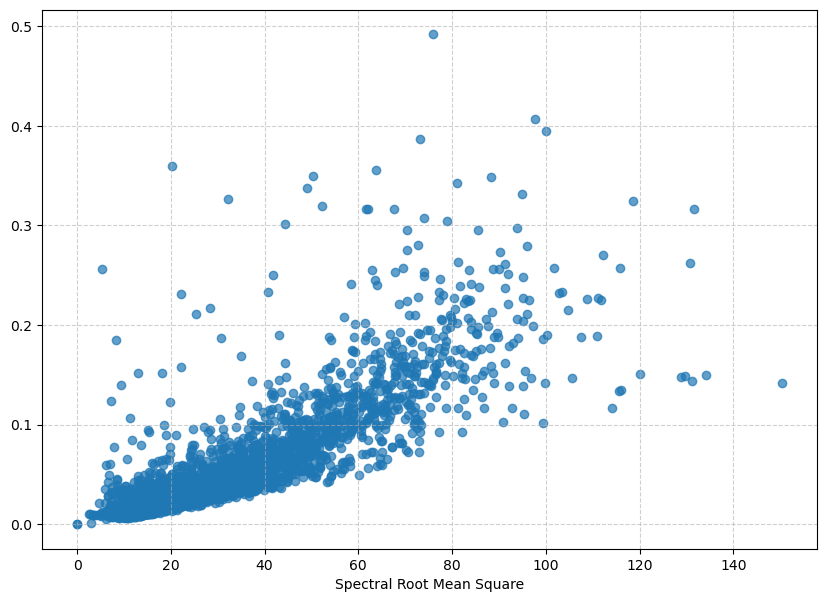

In [14]:
sr=48000
y, sr = af.read("..\..\corpus\piano_sample_1\input.wav", samplate=sr) # sr is 48kHz

grain_duration = 0.1 # in s
grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
centroid_arr = spectral_obj.kurtosis(spec_arr)

n_clusters=3
x = np.array([[i, j] for i, j in zip(rms_arr, centroid_arr)])
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters, n_init='auto', random_state=0).fit(x)
plt.figure(figsize=(10, 7))
plt.scatter(centroid_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

dict_clusters = {}
for idx, lab in enumerate(kmeans.labels_):
    dict_clusters[lab] = dict_clusters.get(lab, [])
    dict_clusters[lab].append(idx)


In [15]:
frequency_matrix = np.zeros((n_clusters, n_clusters))
labels = kmeans.labels_
prev_label = labels[0]
for label_idx in range(1, len(labels)):
    frequency_matrix[prev_label][labels[label_idx]] += 1
    prev_label = labels[label_idx]
total_freq = np.sum(frequency_matrix)

probability_matrix = []#np.zeros((n_clusters, n_clusters))
for i in frequency_matrix:
    row = i / np.sum(i)
    probability_matrix.append(row)
transition_matrix_fin = np.array(probability_matrix)
transition_matrix_fin

array([[0.69660194, 0.29368932, 0.00970874],
       [0.05504587, 0.75433231, 0.19062181],
       [0.0393134 , 0.06644518, 0.89424142]])

This section of the notebook concerns actual synthesis

In [10]:
output_buffer = np.array([]) 
curr_label = 3
n_iterations = 100
seed = 100
s = np.random.seed(seed)

for i in range(n_iterations):

    next_label = np.random.choice(range(n_clusters), p=transition_matrix_fin[curr_label])
    grain_idx = np.random.choice(dict_clusters[next_label]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    output_buffer = np.concatenate([output_buffer, grain])
    curr_label = next_label
# output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_test_{n_iterations}_{grain_size}_{sr}_{curr_label}.wav", output_buffer, samplerate=sr)

Xenaxis matrix:
state 1: (c0,d0)
state 2: (c0,d1)
state 3: (c1,d1)
state 4: (c1,d2)
state 4: (c2,d2)
etc. ... 

Take n_clusters as possibilities for waveforms c0,c1,c2,...

Take densities as densities per $\Delta t$ d0,d1,d2,...

Values: 1, 3, 9/ $\Delta t$



In [41]:
n_densities = 3
n_states = n_densities * n_clusters
# np.random.seed(1)
randomized_matrix = np.random.rand(n_states,n_states)
mtp = []
for i in randomized_matrix:
    row = i / np.sum(i)
    mtp.append(row)
mtp = np.array(mtp)
mtp

array([[0.11202226, 0.13488218, 0.06266814, 0.04848369, 0.16091657,
        0.07689254, 0.17330187, 0.1191655 , 0.11166724],
       [0.02720627, 0.22512388, 0.10667416, 0.13713616, 0.09676923,
        0.05619909, 0.21419126, 0.13601939, 0.00068055],
       [0.11888259, 0.06292265, 0.10152888, 0.17066185, 0.06882201,
        0.17501402, 0.12007985, 0.0030477 , 0.17904046],
       [0.13280225, 0.19170257, 0.0331268 , 0.02635984, 0.17926085,
        0.13394041, 0.01268637, 0.14521296, 0.14490794],
       [0.26536749, 0.20456178, 0.03572762, 0.00571549, 0.0075356 ,
        0.00813805, 0.07078513, 0.24725611, 0.15491273],
       [0.11678001, 0.17787349, 0.0262308 , 0.05897572, 0.1237378 ,
        0.20482073, 0.11851395, 0.00393912, 0.16912839],
       [0.05954522, 0.20628569, 0.09913219, 0.22071018, 0.19095467,
        0.14216784, 0.0348762 , 0.01531419, 0.03101382],
       [0.01362289, 0.03286912, 0.06901649, 0.21801488, 0.17114799,
        0.00383932, 0.022008  , 0.29576984, 0.17371146],


In [25]:
state_dict = {}
densities = [1,3,9]
clusters = list(range(n_clusters))
states = []
for i in range(n_clusters):
    for j in range(n_densities):
        states.append([
            clusters[i], densities[j]
        ])
# for i in range(n_states):


In [ ]:
# TODO: 
n_iterations = 100
seed = 100
s = np.random.seed(seed)

delta_t = 1 # in seconds
delta_t_samples = int(delta_t * sr)
curr_state = 8
output_buffer = np.zeros(n_iterations*delta_t_samples) 

n_streams = 4

for stream in range(n_streams):
    stream_buffer = np.array([]) 
    print(f"Synthesizing stream {stream}")
    for _ in range(n_iterations):
        temp_buffer = np.zeros(delta_t_samples)

        next_state = np.random.choice(range(n_states), p=mtp[curr_state])
        # print(next_state)
        cluster, density = states[next_state][0], states[next_state][1]

        grain_idx = np.random.choice(dict_clusters[cluster]) # uniform sampling from a cluster
        grain_y_idx = grains[grain_idx]
        grain = y[grain_y_idx:grain_y_idx+grain_size]
        grain = grain * np.hanning(grain_size)
        incr = int(temp_buffer.shape[-1] // density)
        for i in range(density):
            e = i*incr + len(grain)
            if e > temp_buffer.shape[-1]:
                e = temp_buffer.shape[-1]
            temp_buffer[i*incr:e] = temp_buffer[i*incr:e] + grain[:len(temp_buffer[i*incr:e])]
        temp_buffer = temp_buffer * np.hanning(temp_buffer.shape[-1])
        stream_buffer = np.concatenate([output_buffer, temp_buffer])
        curr_state = next_state
        stream_buffer = stream_buffer
    print(np.max(stream_buffer))
    print(np.max(output_buffer))
    print(f"Finished synthesizing stream {stream}")
output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_parallel_test_{n_iterations}_{grain_size}_{sr}_{delta_t}.wav", output_buffer, samplerate=sr)

Synthesizing stream 0
0.03851844246783955
0.0
Finished synthesizing stream 0
Synthesizing stream 1
0.02909838555510682
0.0
Finished synthesizing stream 1
Synthesizing stream 2
0.28160938695845605
0.0
Finished synthesizing stream 2
Synthesizing stream 3
0.17403489123557647
0.0
Finished synthesizing stream 3


C:\Users\hippo\AppData\Local\Temp\ipykernel_18928\753830967.py:41: RuntimeWarning: invalid value encountered in divide
  output_buffer / np.max(np.abs(output_buffer))


In [ ]:
# TODO: 
output_buffer = np.array([]) 
n_iterations = 100
seed = 100
s = np.random.seed(seed)

delta_t = 1 # in seconds
delta_t_samples = int(delta_t * sr)
curr_state = 8

for _ in range(n_iterations):
    temp_buffer = np.zeros(delta_t_samples)

    next_state = np.random.choice(range(n_states), p=mtp[curr_state])
    print(next_state)
    cluster, density = states[next_state][0], states[next_state][1]

    grain_idx = np.random.choice(dict_clusters[cluster]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    incr = int(temp_buffer.shape[-1] // density)
    for i in range(density):
        e = i*incr + len(grain)
        if e > temp_buffer.shape[-1]:
            e = temp_buffer.shape[-1]
        temp_buffer[i*incr:e] = temp_buffer[i*incr:e] + grain[:len(temp_buffer[i*incr:e])]
    temp_buffer = temp_buffer * np.hanning(temp_buffer.shape[-1])
    output_buffer = np.concatenate([output_buffer, temp_buffer])
    curr_state = next_state
# output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_NEW_test_{n_iterations}_{grain_size}_{sr}_{delta_t}_{densities[-1]}_{n_clusters[-1]}.wav", output_buffer, samplerate=sr)

6
8
1
6
4
4
4
1
0
8
1
2
4
5
1
4
0
6
0
3
2
1
0
0
4
7
5
7
5
6
2
1
8
0
8
1
6
5
3
6
2
7
8
4
6
2
5
8
4
3
8
5
2
8
2
7
2
1
2
3
5
1
2
6
2
1
0
5
7
2
7
7
3
2
3
2
6
7
4
4
3
5
0
4
0
1
8
7
7
5
2
3
5
1
4
3
6
5
3
8
